# LAB 2 - Notebook bài mẫu: Chuẩn bị dữ liệu IoT cho AI, train baseline và chuẩn bị deploy model

**Case mẫu:** Smart Classroom Occupancy & Air Quality  
**Dataset chính:** UCI Occupancy Detection  
**Mục tiêu notebook:** chạy trọn vẹn luồng `telemetry → clean data → feature dataset → baseline model → decision log → model artifact`.

> Sau notebook này, sinh viên sẽ dùng file `models/occupancy_baseline.joblib` để deploy bằng FastAPI ở bước tiếp theo.

# ## 0. Sinh viên cần hiểu project này trước khi chạy

"""
Project mẫu gồm các phần chính:

| Thành phần | Vai trò |
|---|---|
| `data/` | Chứa dữ liệu public Air Quality hoặc dữ liệu fallback |
| `notebooks/` | Notebook xử lý dữ liệu và train baseline |
| `src/data_utils.py` | Các hàm dùng chung: tải data, clean, train, decision |
| `src/app.py` | FastAPI dùng để deploy model sau khi train |
| `models/` | Chứa file model `.joblib` |
| `outputs/` | Chứa metric, decision log và biểu đồ kiểm tra |

Bài toán: Dự đoán nồng độ CO dựa trên dữ liệu từ cảm biến chất lượng không khí.
"""

## 1. Import thư viện và thiết lập đường dẫn

Cell này giúp notebook nhận ra thư mục gốc của project, kể cả khi mở notebook từ thư mục `notebooks/`.

In [1]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/vinh_shindo/AIoT/Tuan2


## 2. Tải hoặc nạp dataset

Notebook ưu tiên dataset công khai **UCI Air Quality Dataset**.
Nếu máy không có Internet hoặc tải thất bại, project sẽ dùng file fallback.

Dữ liệu gốc có các trường chính:
- DateTime (timestamp)
- PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), PT08.S5(O3) - Cảm biến khí
- Temperature, Relative Humidity, Absolute Humidity
- CO(GT) - Nồng độ CO thực tế (target)

In [2]:
from src.data_utils import ensure_dataset, check_schema, RAW_FEATURES, TARGET_COL, API_FEATURES


In [3]:
raw_df, dataset_status = ensure_dataset(prefer_public=True)
print("Dataset source:", dataset_status["dataset_source"])
for msg in dataset_status["messages"]:
    print("-", msg)

print()
print("Shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))
display(raw_df.head())


Dataset source: UCI Air Quality Dataset
- OK: AirQualityUCI.csv already exists.

Shape: (9357, 10)
Columns: ['DateTime', 'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'Temperature', 'Relative_Humidity', 'Absolute_Humidity', 'CO_GT']


,DateTime,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative_Humidity,Absolute_Humidity,CO_GT
0,2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,2.6
1,2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,2.0
2,2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,2.2
3,2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,2.2
4,2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,1.6


## 3. Kiểm tra schema telemetry

Ở hệ thống AIoT thật, bước này giúp phát hiện lỗi trước khi train model:
- thiếu cột;
- sai kiểu dữ liệu;
- duplicate;
- timestamp không parse được;
- sensor value nằm ngoài miền hợp lý.

In [4]:
schema_report = check_schema(raw_df)
print(json.dumps(schema_report, ensure_ascii=False, indent=2))

{
  "required_columns": [
    "DateTime",
    "PT08.S1(CO)",
    "PT08.S2(NMHC)",
    "PT08.S3(NOx)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)",
    "Temperature",
    "Relative_Humidity",
    "Absolute_Humidity",
    "CO_GT"
  ],
  "missing_columns": [],
  "duplicated_rows": 0,
  "n_rows": 9357,
  "n_columns": 10
}


## 4. Làm sạch dữ liệu IoT

Các lỗi xử lý trong bài mẫu:
- Timestamp sai hoặc rỗng.
- Dòng trùng lặp.
- Sensor outlier: giá trị cảm biến vượt ngưỡng vật lý.
- Missing value (được đánh dấu bằng -200).

Chiến lược xử lý:
- Parse datetime từ Date và Time.
- Xóa duplicate.
- Đưa outlier về NaN.
- Nội suy tuyến tính theo thời gian, sau đó ffill/bfill.

In [5]:
from src.data_utils import clean_iot_data

clean_df, cleaning_report = clean_iot_data(raw_df)

print(json.dumps(cleaning_report, ensure_ascii=False, indent=2))
print("\nClean shape:", clean_df.shape)
display(clean_df.head())

clean_df.to_csv(PROJECT_ROOT / "data" / "telemetry_clean.csv", index=False)

{
  "before_rows": 9357,
  "after_rows": 9357,
  "removed_rows": 0,
  "bad_timestamp_rows": 0,
  "duplicate_rows": 0,
  "duplicate_timestamps": 0,
  "outlier_counts": {
    "PT08.S1(CO)": 0,
    "PT08.S2(NMHC)": 0,
    "PT08.S3(NOx)": 3,
    "PT08.S4(NO2)": 522,
    "PT08.S5(O3)": 159,
    "Temperature": 0
  },
  "missing_before_fill": {
    "PT08.S1(CO)": 366,
    "PT08.S2(NMHC)": 366,
    "PT08.S3(NOx)": 369,
    "PT08.S4(NO2)": 888,
    "PT08.S5(O3)": 525,
    "Temperature": 366,
    "Relative_Humidity": 366,
    "Absolute_Humidity": 366
  }
}

Clean shape: (9357, 11)


,DateTime,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative_Humidity,Absolute_Humidity,CO_GT,timestamp
0,2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,2.6,2004-03-10 18:00:00
1,2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,2.0,2004-03-10 19:00:00
2,2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,2.2,2004-03-10 20:00:00
3,2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,2.2,2004-03-10 21:00:00
4,2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,1.6,2004-03-10 22:00:00


## 5. Tạo feature dataset

Feature trong bài mẫu gồm:
- Feature gốc: 5 cảm biến khí (PT08.S1-S5), Temperature, Relative Humidity, Absolute Humidity.
- Feature thời gian: hour, dayofweek.
- Feature giải thích/decision log: rolling mean cho các cảm biến chính.

Lưu ý: API deploy ở Lab 2 chỉ dùng feature đơn giản để sinh viên dễ hiểu input/output.

In [6]:
from src.data_utils import create_features

feature_df = create_features(clean_df)
feature_df.to_csv(PROJECT_ROOT / "data" / "feature_dataset.csv", index=False)

# Hiển thị các cột feature
feature_columns = ["timestamp"] + [col for col in RAW_FEATURES if col in feature_df.columns] + ["hour", "dayofweek", TARGET_COL]
available_cols = [col for col in feature_columns if col in feature_df.columns]
display(feature_df[available_cols].head())

,timestamp,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),Temperature,Relative_Humidity,Absolute_Humidity,hour,dayofweek,CO_GT
0,2004-03-10 18:00:00,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578,18,2,2.6
1,2004-03-10 19:00:00,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255,19,2,2.0
2,2004-03-10 20:00:00,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502,20,2,2.2
3,2004-03-10 21:00:00,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867,21,2,2.2
4,2004-03-10 22:00:00,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888,22,2,1.6


## 6. Chia train/test theo thời gian

Với dữ liệu IoT dạng time-series, không nên chia ngẫu nhiên như nhiều bài ML cơ bản.

Cách chia ở bài mẫu:
- 75% dữ liệu đầu theo thời gian → train
- 25% dữ liệu sau theo thời gian → test

In [7]:
from src.data_utils import time_train_test_split

train_df, test_df = time_train_test_split(feature_df, test_ratio=0.25)

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max(), train_df.shape)
print("Test :", test_df["timestamp"].min(), "→", test_df["timestamp"].max(), test_df.shape)
print("\nTrain CO statistics:")
display(train_df[TARGET_COL].describe())

Train: 2004-03-10 18:00:00 → 2004-12-28 02:00:00 (7017, 16)
Test : 2004-12-28 03:00:00 → 2005-04-04 14:00:00 (2340, 16)

Train CO statistics:


count    7017.000000
mean        2.107582
std         1.327145
min         0.100000
25%         1.300000
50%         1.800000
75%         2.600000
max        11.900000
Name: CO_GT, dtype: float64

## 7. Train AI baseline đầu tiên

Baseline model: **Linear Regression** (vì bài toán hồi quy).

Vì sao chọn Linear Regression?
- Dễ giải thích cho sinh viên mới deploy model.
- Chạy nhanh, ít lỗi thư viện.
- Dễ dàng xem feature importance qua coefficients.
- Phù hợp làm baseline trước khi dùng model phức tạp hơn.

Input model:
`8 cảm biến + Temperature + Humidity + hour + dayofweek`

Output model:
`predicted CO concentration (mg/m³)`

In [8]:
from src.data_utils import API_FEATURES, train_baseline_model, evaluate_model

model = train_baseline_model(train_df)
metrics = evaluate_model(model, test_df)

print("Features dùng cho model:", API_FEATURES)
print("\nModel Metrics (Regression):")
print(json.dumps(metrics, ensure_ascii=False, indent=2))

Features dùng cho model: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'Temperature', 'Relative_Humidity', 'Absolute_Humidity', 'hour', 'dayofweek']

Model Metrics (Regression):
{
  "mse": 0.49877386112135036,
  "rmse": 0.7062392378800192,
  "mae": 0.5122144859534017,
  "r2": 0.7089396219412848
}


## 8. AI baseline phụ: anomaly score bằng Z-score

Lab 2 chưa đi sâu anomaly detection, vì Lab 3 sẽ học kỹ hơn.  
Tuy nhiên bài mẫu vẫn tạo `anomaly_score` để decision layer biết khi nào không nên tự động điều khiển.

Ý tưởng:
- Tính mean/std trên tập train cho từng sensor.
- Tính `Z-score = |x - mean| / std` cho từng sensor.
- Lấy `max Z-score` làm anomaly_score.
- Nếu anomaly_score >= 3: đánh dấu is_anomaly = True.

In [9]:
from src.data_utils import compute_train_stats, compute_anomaly_score, RAW_FEATURES

train_stats = compute_train_stats(train_df)
sample_scores = compute_anomaly_score(test_df[RAW_FEATURES].head(10), train_stats)

print("Train stats (first 2 sensors):")
first_sensors = list(train_stats.keys())[:2]
for sensor in first_sensors:
    print(f"  {sensor}: mean={train_stats[sensor]['mean']:.2f}, std={train_stats[sensor]['std']:.2f}")

print("\nAnomaly score 10 dòng đầu tập test:")
print(sample_scores)

Train stats (first 2 sensors):
  PT08.S1(CO): mean=1100.80, std=222.09
  PT08.S2(NMHC): mean=966.96, std=269.20

Anomaly score 10 dòng đầu tập test:
[1.76846928 1.84765242 2.25544562 1.97830461 1.4338036  1.65875041
 1.66451828 1.30995525 1.17459569 1.00698907]


## 9. Sinh decision log

Decision log là phần giúp Lab 2 không dừng ở train/test model.

Mỗi dòng decision log cho thấy:
- dữ liệu đầu vào (cảm biến);
- output AI (dự đoán CO);
- giá trị CO thực tế;
- cờ bất thường;
- quyết định/cảnh báo dựa trên WHO guidelines;
- gợi ý command;
- safety note.

Đây chính là cầu nối sang Dashboard/Command/Feedback của hệ thống AIoT.

In [10]:
from src.data_utils import make_decision_log

decision_log = make_decision_log(model, test_df, train_stats, n_rows=200)
decision_log.to_csv(PROJECT_ROOT / "outputs" / "decision_log.csv", index=False)

display(decision_log.head(10))
print("Decision log shape:", decision_log.shape)
print("\nDecision counts:")
display(decision_log["decision"].value_counts())

,timestamp,PT08_S1_CO,PT08_S2_NMHC,PT08_S3_NOx,Temperature,Relative_Humidity,co_prediction,actual_co,anomaly_score,is_anomaly,decision,command_hint,safety_note,air_quality_level
0,2005-03-27 07:00:00,1082.0,720.0,697.0,15.6,67.7,1.5214,1.1,1.1223,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
1,2005-03-27 08:00:00,1068.0,688.0,725.0,15.2,71.5,1.4457,1.1,1.3415,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
2,2005-03-27 09:00:00,1136.0,733.0,692.0,14.5,80.8,1.7332,1.1,1.8779,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
3,2005-03-27 10:00:00,1184.0,743.0,672.0,15.2,81.4,1.8372,1.4,1.9125,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
4,2005-03-27 11:00:00,1179.0,738.0,680.0,15.9,77.3,1.8165,1.3,1.6761,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
5,2005-03-27 12:00:00,1182.0,761.0,677.0,17.5,67.1,1.8338,1.5,1.0877,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
6,2005-03-27 13:00:00,1082.0,700.0,759.0,18.1,62.8,1.4891,1.3,0.9917,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
7,2005-03-27 14:00:00,996.0,620.0,820.0,18.6,62.1,1.1175,0.8,1.2889,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
8,2005-03-27 15:00:00,1024.0,630.0,862.0,16.2,71.9,1.2981,0.9,1.3646,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good
9,2005-03-27 16:00:00,1093.0,682.0,797.0,15.4,75.2,1.6048,1.4,1.5549,False,AIR_QUALITY_GOOD,NORMAL_OPERATION,"Chất lượng không khí tốt, duy trì hoạt động bì...",Good


Decision log shape: (200, 14)

Decision counts:


decision
AIR_QUALITY_GOOD            147
AIR_QUALITY_MODERATE         49
AIR_QUALITY_POOR              2
CHECK_SENSOR_CALIBRATION      2
Name: count, dtype: int64

## 10. Lưu model và artifact để deploy

Sau khi train, ta không copy code notebook vào API.  
Ta lưu model thành file `.joblib`, sau đó FastAPI sẽ load file này.

Các artifact cần có:
- `models/air_quality_model.joblib`
- `outputs/metrics.json`
- `outputs/decision_log.csv`
- `data/feature_dataset.csv`

In [11]:
from src.data_utils import save_artifacts

save_artifacts(
    model=model,
    feature_cols=API_FEATURES,
    train_stats=train_stats,
    metrics=metrics,
    dataset_status=dataset_status
)

print("Saved model:", PROJECT_ROOT / "models" / "air_quality_model.joblib")
print("Saved metrics:", PROJECT_ROOT / "outputs" / "metrics.json")
print("Saved decision log:", PROJECT_ROOT / "outputs" / "decision_log.csv")

Saved model: /home/vinh_shindo/AIoT/Tuan2/models/air_quality_model.joblib
Saved metrics: /home/vinh_shindo/AIoT/Tuan2/outputs/metrics.json
Saved decision log: /home/vinh_shindo/AIoT/Tuan2/outputs/decision_log.csv


## 11. Vẽ biểu đồ kiểm tra nhanh

Sinh viên cần xem biểu đồ để hiểu model:
- CO dự đoán vs CO thực tế theo thời gian.
- Residual plot để kiểm tra lỗi dự đoán.
- Feature importance từ coefficients của Linear Regression.

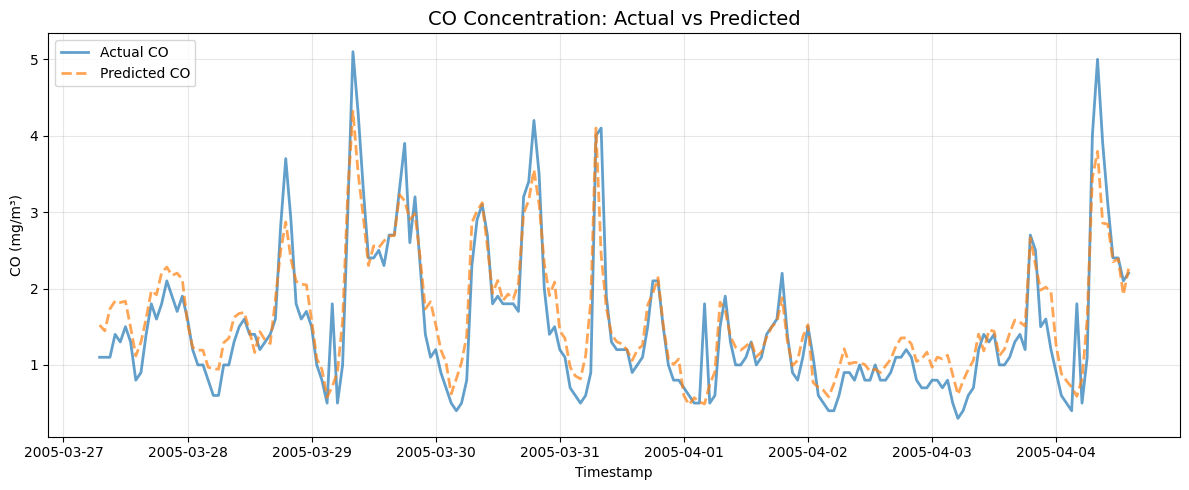

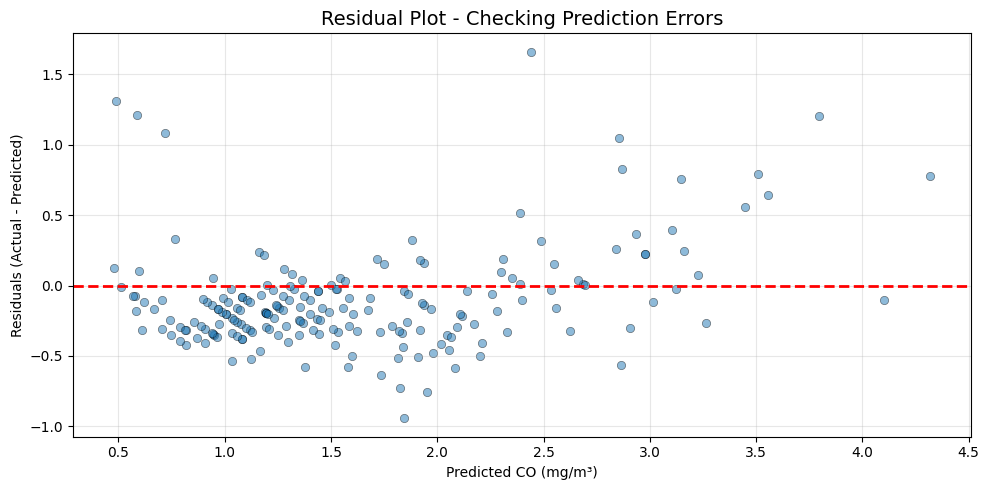

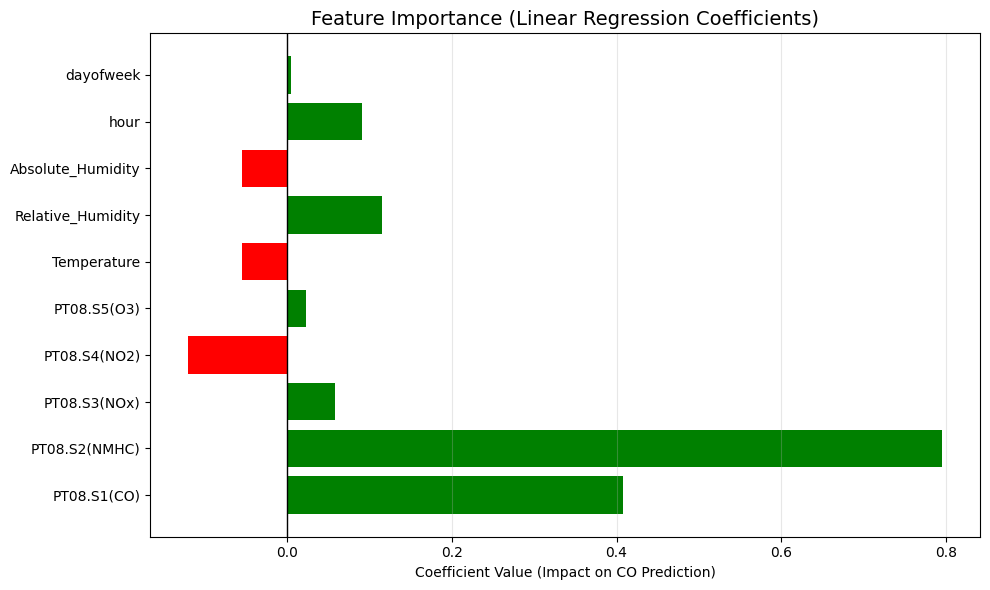

Saved figures to: /home/vinh_shindo/AIoT/Tuan2/outputs/figures


In [12]:
import matplotlib.pyplot as plt
import numpy as np

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1) CO predictions vs actual
plt.figure(figsize=(12, 5))
test_sample = test_df.tail(200)
preds = model.predict(test_sample[API_FEATURES])
plt.plot(test_sample["timestamp"], test_sample[TARGET_COL].values, label="Actual CO", alpha=0.7, linewidth=2)
plt.plot(test_sample["timestamp"], preds, label="Predicted CO", alpha=0.7, linewidth=2, linestyle='--')
plt.title("CO Concentration: Actual vs Predicted", fontsize=14)
plt.xlabel("Timestamp")
plt.ylabel("CO (mg/m³)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_co_predictions.png", dpi=160)
plt.show()

# 2) Residual plot
residuals = test_sample[TARGET_COL].values - preds
plt.figure(figsize=(10, 5))
plt.scatter(preds, residuals, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title("Residual Plot - Checking Prediction Errors", fontsize=14)
plt.xlabel("Predicted CO (mg/m³)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_residual_plot.png", dpi=160)
plt.show()

# 3) Feature importance (coefficients)
coefficients = model.named_steps["regressor"].coef_
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(API_FEATURES, coefficients, color=colors)
plt.title("Feature Importance (Linear Regression Coefficients)", fontsize=14)
plt.xlabel("Coefficient Value (Impact on CO Prediction)")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_feature_importance.png", dpi=160)
plt.show()

print("Saved figures to:", FIGURES_DIR)

## 12. Kiểm tra hoàn thành phần notebook

Nếu cell này chạy thành công, sinh viên đã hoàn thành phần data preparation + baseline model.

Sau bước này, chuyển sang terminal để deploy:

```bash
uvicorn src.app:app --reload --host 127.0.0.1 --port 8000
```

Sau đó mở terminal thứ hai:

```bash
python src/test_api.py
python src/check_outputs.py
```

In [13]:
from pathlib import Path

required_files = [
    PROJECT_ROOT / "data" / "telemetry_clean.csv",
    PROJECT_ROOT / "data" / "feature_dataset.csv",
    PROJECT_ROOT / "models" / "air_quality_model.joblib", # Đã đổi tên
    PROJECT_ROOT / "outputs" / "metrics.json",
    PROJECT_ROOT / "outputs" / "decision_log.csv",
    PROJECT_ROOT / "outputs" / "figures" / "01_co_predictions.png", # Ảnh mới
    PROJECT_ROOT / "outputs" / "figures" / "02_residual_plot.png", # Ảnh mới
    PROJECT_ROOT / "outputs" / "figures" / "03_feature_importance.png", # Ảnh mới
]

for path in required_files:
    status = "OK" if path.exists() and path.stat().st_size > 0 else "MISS"
    print(f"{status} {path.relative_to(PROJECT_ROOT)}")

assert all(path.exists() and path.stat().st_size > 0 for path in required_files)


OK data/telemetry_clean.csv
OK data/feature_dataset.csv
OK models/air_quality_model.joblib
OK outputs/metrics.json
OK outputs/decision_log.csv
OK outputs/figures/01_co_predictions.png
OK outputs/figures/02_residual_plot.png
OK outputs/figures/03_feature_importance.png
